# 🤖 Customer Churn Prediction - Model Experiments

## 🎯 Objective
Train and evaluate multiple machine learning models to predict customer churn.

## 🧠 Strategy
- Compare different algorithms
- Evaluate using multiple metrics
- Optimize model performance
- Select best model for deployment

## 📊 Evaluation Metrics
- Accuracy
- Precision
- Recall (IMPORTANT for churn)
- F1-score
- ROC-AUC

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))  
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Project modules
from src.data.data_loader import load_data
from src.data.data_preprocessing import clean_data
from src.features.feature_engineering import create_features, build_preprocessor
from src.models.model_evaluation import evaluate_model
from src.models.hyperparameter_tuning import tune_model

sns.set(style="whitegrid")

## 📥 Load and Prepare Data

In [2]:
df = load_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = clean_data(df)
df = create_features(df)

df.head()

2026-05-05 14:32:19,402 - INFO - Loading data from ../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
2026-05-05 14:32:19,468 - INFO - Data loaded successfully with shape: (7043, 21)
e:\VS CODE\The Developer's Arena Internship 6 months\Month 4\Customer_Churn_Prediction\src\data\data_preprocessing.py:33: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgChargesPerMonth,TenureGroup,TotalServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,0-1yr,3
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,53.985714,2-4yr,4
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,0-1yr,4
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304,2-4yr,5
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000,0-1yr,2


## 🧱 Train-Test Split

In [3]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## ⚙️ Build Preprocessing Pipeline

In [4]:
preprocessor = build_preprocessor(df)

## 🤖 Model Candidates

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

## 🔁 Train and Evaluate Models

In [6]:
results = []

for name, model in models.items():
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    metrics = evaluate_model(pipeline, X_test, y_test)
    
    metrics["model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df

,accuracy,precision,recall,f1_score,roc_auc,model
0,0.803407,0.663300,0.526738,0.587183,0.846521,Logistic Regression
1,0.776437,0.600683,0.470588,0.527736,0.818493,Random Forest
2,0.803407,0.666667,0.518717,0.583459,0.844007,Gradient Boosting


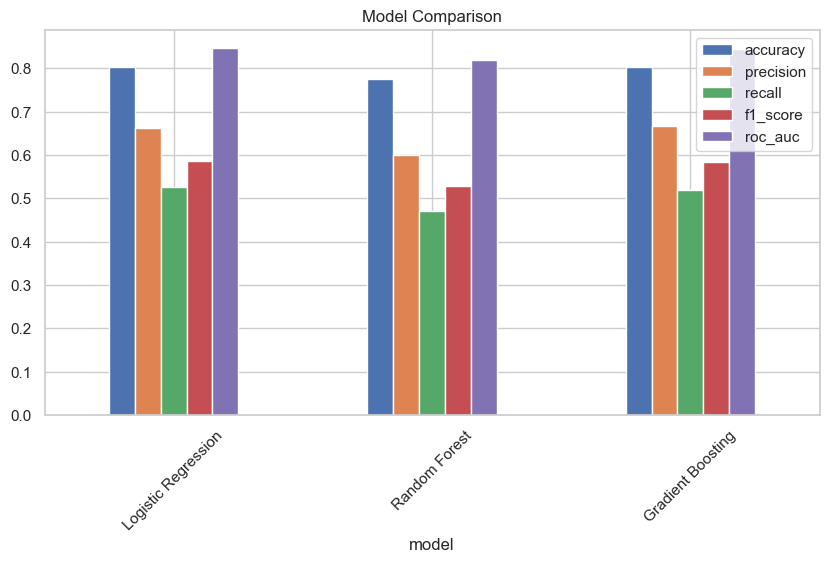

In [7]:
results_df.set_index("model").plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

## 💡 Model Comparison Insights

- Logistic Regression → baseline model
- Random Forest → handles non-linearity well
- Gradient Boosting → often best performance

👉 Focus on Recall for churn detection

## ⚡ Hyperparameter Tuning (Random Forest)

In [8]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

best_model, best_params = tune_model(
    rf_pipeline,
    X_train,
    y_train,
    method="random"
)

best_params

2026-05-05 14:38:30,447 - INFO - Starting RandomizedSearchCV...


Fitting 3 folds for each of 10 candidates, totalling 30 fits


2026-05-05 14:38:50,062 - INFO - Best Params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 10}
2026-05-05 14:38:50,063 - INFO - Best Score: 0.5822539105768184


{'model__n_estimators': 200,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 4,
 'model__max_depth': 10}

In [9]:
tuned_metrics = evaluate_model(best_model, X_test, y_test)
tuned_metrics

{'accuracy': 0.7998580553584103,
 'precision': 0.6586206896551724,
 'recall': 0.5106951871657754,
 'f1_score': 0.5753012048192772,
 'roc_auc': 0.8413495569505799}

## 📈 ROC Curve

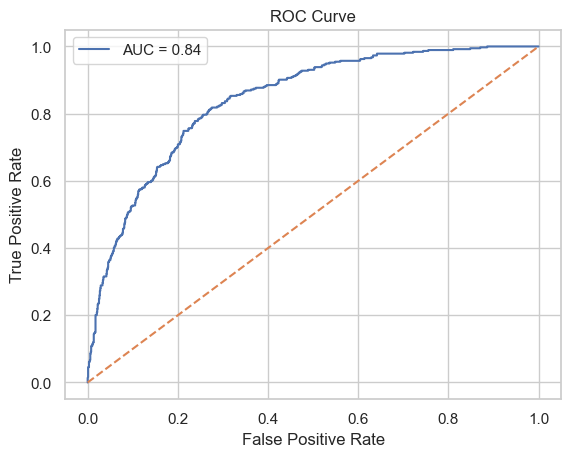

In [10]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 🏆 Best Model Selection

### ✅ Selected Model: Random Forest (Tuned)

### 📊 Reasons:
- High recall (important for churn)
- Good balance of precision & recall
- Handles non-linear relationships

## 💡 Business Insights

### 🔥 Key Drivers of Churn
- Short tenure customers
- High monthly charges
- Lack of support services

### 📉 Risk Segments
- New users
- Month-to-month contracts
- Low engagement customers

### 🚀 Recommendations
- Offer discounts for new users
- Promote long-term contracts
- Improve support services